# Brain Tumour Classification — Training Pipeline

Multi-class MRI classification: **glioma**, **meningioma**, **pituitary tumour**, **no tumour**  
Dataset: [Kaggle — Brain Tumor Classification (MRI)](https://www.kaggle.com/datasets/sartajbhuvaji/brain-tumor-classification-mri/data)

**Pipeline features**
- All hyper-parameters live in a single `TrainingConfig` dataclass
- Plug-in model registry (`resnet18`)
- Separate augmented train transforms vs deterministic val/test transforms
- Class-weighted cross-entropy to handle label imbalance
- Per-class one-vs-rest AUROC as the primary metric (matches evaluation protocol)
- Cosine LR schedule with linear warm-up
- Early stopping + best-checkpoint saving
- Grid-search helper for hyperparameter sweeps

## 1. Setup

In [1]:
%matplotlib inline
import os
import time
import random
import itertools
from copy import deepcopy
from dataclasses import dataclass, asdict
from typing import Dict, List, Tuple, Any, Optional

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import torchvision.transforms.v2 as v2
import torchvision.models as models
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
from tqdm.auto import tqdm

from BrainTumorDatasetClass import BrainTumorDataset
from model import PoPEViT, RoPEViT

# ── Reproducibility ───────────────────────────────────────────────────────────
def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

# ── Device ────────────────────────────────────────────────────────────────────
DEVICE = (
    torch.device('mps')  if torch.backends.mps.is_available()  else
    torch.device('cuda') if torch.cuda.is_available()           else
    torch.device('cpu')
)
print(f'Device: {DEVICE}')

# ── Constants ─────────────────────────────────────────────────────────────────
CLASS_NAMES = ['no_tumor', 'meningioma_tumor', 'glioma_tumor', 'pituitary_tumor']
_LABEL_MAP = {name: i for i, name in enumerate(CLASS_NAMES)}
NUM_CLASSES = len(CLASS_NAMES)
# ImageNet normalisation constants (required by all pretrained torchvision models)
_IMG_MEAN = [0.485, 0.456, 0.406]
_IMG_STD = [0.229, 0.224, 0.225]


Device: mps


/Users/lwagner/develop/uni/msc/aml/aml2026-group-09/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
@dataclass
class TrainingConfig:
    """Single source of truth for every tunable hyperparameter."""

    # ── Data ──────────────────────────────────────────────────────────────
    data_dir:           str   = 'Brain-Tumor-Classification-DataSet'
    image_size:         int   = 224
    batch_size:         int   = 32
    num_workers:        int   = 0

    # Training-time augmentation (val / test never see these)
    variants_per_image: int   = 3
    aug_degrees:        float = 15.0
    aug_translate:      tuple = (0.05, 0.05)
    aug_scale:          tuple = (0.95, 1.05)
    aug_shear:          float = 5.0
    aug_hflip_p:        float = 0.5

    # ── Model ─────────────────────────────────────────────────────────────
    model_name: str   = 'popevit'       # key used by build_model()
    dropout:    float = 0.1

    # ViT-specific (ignored by CNN models)
    patch_size:  int = 16
    vit_dim:     int = 512
    vit_depth:   int = 6
    vit_heads:   int = 8
    vit_mlp_dim: int = 1024

    # ── Optimiser ─────────────────────────────────────────────────────────
    optimizer:     str   = 'adamw'
    learning_rate: float = 3e-4
    weight_decay:  float = 1e-2

    # ── LR Scheduler ──────────────────────────────────────────────────────
    scheduler:     str = 'cosine'
    warmup_epochs: int = 5

    # ── Training loop ─────────────────────────────────────────────────────
    epochs:                  int = 30
    early_stopping_patience: int = 8

    # ── Run metadata ──────────────────────────────────────────────────────
    seed:           int = 42
    run_name:       str = 'run'
    checkpoint_dir: str = 'checkpoints'

## 2. Dataset

In [3]:
# ── Channel normalisation ─────────────────────────────────────────────────────
class EnsureRGB:
    """Convert any image tensor to exactly 3 channels.

    - 1-ch grayscale -> replicate across RGB channels
    - 4-ch RGBA      -> drop alpha
    - 3-ch RGB       -> pass through unchanged
    """
    def __call__(self, img: torch.Tensor) -> torch.Tensor:
        c = img.shape[0]
        if c == 1:
            return img.repeat(3, 1, 1)
        if c == 4:
            return img[:3]
        return img

    def __repr__(self) -> str:
        return 'EnsureRGB()'


def get_train_transforms(cfg: TrainingConfig) -> v2.Compose:
    """Augmented pipeline for training data."""
    return v2.Compose([
        v2.Resize((cfg.image_size, cfg.image_size), antialias=True),
        EnsureRGB(),
        v2.RandomAffine(
            degrees=cfg.aug_degrees,
            translate=cfg.aug_translate,
            scale=cfg.aug_scale,
            shear=cfg.aug_shear,
        ),
        v2.RandomHorizontalFlip(p=cfg.aug_hflip_p),
        v2.ToDtype(torch.float32, scale=True),
        v2.Normalize(mean=_IMG_MEAN, std=_IMG_STD),
    ])


def get_val_transforms(cfg: TrainingConfig) -> v2.Compose:
    """Deterministic preprocessing only — no augmentation."""
    return v2.Compose([
        v2.Resize((cfg.image_size, cfg.image_size), antialias=True),
        EnsureRGB(),
        v2.ToDtype(torch.float32, scale=True),
        v2.Normalize(mean=_IMG_MEAN, std=_IMG_STD),
    ])

In [4]:
def _val_dir(cfg: TrainingConfig) -> str:
    """Return 'val' or 'dev' depending on which exists in data_dir."""
    for name in ('val', 'dev'):
        if os.path.isdir(os.path.join(cfg.data_dir, name)):
            return name
    raise FileNotFoundError(
        f'Neither val/ nor dev/ found under {cfg.data_dir}. '
        f'Run create_train_test_dev_split.py first.'
    )


def get_dataloaders(cfg: TrainingConfig) -> Dict[str, DataLoader]:
    """Build train / val / test DataLoaders from config."""
    pin = (DEVICE.type == 'cuda')
    kw  = dict(num_workers=cfg.num_workers, pin_memory=pin)
    val_split = _val_dir(cfg)

    train_ds = BrainTumorDataset(
        os.path.join(cfg.data_dir, 'train'),
        transform=get_train_transforms(cfg),
        variants_per_image=cfg.variants_per_image,
    )
    val_ds = BrainTumorDataset(
        os.path.join(cfg.data_dir, val_split),
        transform=get_val_transforms(cfg),
        variants_per_image=1,
    )
    test_ds = BrainTumorDataset(
        os.path.join(cfg.data_dir, 'test'),
        transform=get_val_transforms(cfg),
        variants_per_image=1,
    )
    return {
        'train': DataLoader(train_ds, batch_size=cfg.batch_size, shuffle=True,  **kw),
        'val':   DataLoader(val_ds,   batch_size=cfg.batch_size, shuffle=False, **kw),
        'test':  DataLoader(test_ds,  batch_size=cfg.batch_size, shuffle=False, **kw),
    }

### 2.1 Dataset Overview

In [5]:
def _denorm(img: torch.Tensor) -> np.ndarray:
    """Reverse ImageNet normalisation -> numpy (H, W, C) in [0, 1]."""
    mean = torch.tensor(_IMG_MEAN).view(3, 1, 1)
    std  = torch.tensor(_IMG_STD).view(3, 1, 1)
    return (img.cpu().float() * std + mean).permute(1, 2, 0).clamp(0, 1).numpy()


def show_class_distribution(cfg: TrainingConfig) -> None:
    """Bar chart of raw image counts per class across all splits."""
    val_split = _val_dir(cfg)
    splits = ['train', val_split, 'test']
    split_labels = ['train', 'val', 'test']
    counts: Dict[str, Dict[str, int]] = {}
    for split in splits:
        split_dir = os.path.join(cfg.data_dir, split)
        counts[split] = {
            cls: len(os.listdir(os.path.join(split_dir, cls)))
            for cls in CLASS_NAMES
            if os.path.isdir(os.path.join(split_dir, cls))
        }

    x, w = np.arange(NUM_CLASSES), 0.25
    fig, ax = plt.subplots(figsize=(10, 5))
    colors = ['steelblue', 'darkorange', 'forestgreen']
    for i, (split, label) in enumerate(zip(splits, split_labels)):
        vals = [counts[split].get(c, 0) for c in CLASS_NAMES]
        bars = ax.bar(x + i * w, vals, w, label=label, color=colors[i], alpha=0.85)
        ax.bar_label(bars, padding=2, fontsize=8)
    ax.set_xticks(x + w)
    ax.set_xticklabels(CLASS_NAMES, rotation=15, ha='right')
    ax.set_ylabel('Number of images')
    ax.set_title('Class Distribution across Splits', fontsize=13, fontweight='bold')
    ax.legend()
    plt.tight_layout()
    plt.show()


def show_dataset_samples(cfg: TrainingConfig, samples_per_class: int = 4) -> None:
    """Display sample images from each class (no augmentation applied)."""
    ds = BrainTumorDataset(
        os.path.join(cfg.data_dir, 'train'),
        transform=get_val_transforms(cfg),
        variants_per_image=1,
    )
    # Collect indices per class without loading any images
    class_idx_map: Dict[int, List[int]] = {i: [] for i in range(NUM_CLASSES)}
    for idx, (_, label_str, _) in enumerate(ds.samples):
        cls = _LABEL_MAP[label_str]
        if len(class_idx_map[cls]) < samples_per_class:
            class_idx_map[cls].append(idx)
        if all(len(v) >= samples_per_class for v in class_idx_map.values()):
            break

    fig, axes = plt.subplots(
        NUM_CLASSES, samples_per_class,
        figsize=(samples_per_class * 3, NUM_CLASSES * 3),
    )
    for row, cls in enumerate(range(NUM_CLASSES)):
        for col, idx in enumerate(class_idx_map[cls]):
            img, _ = ds[idx]
            ax = axes[row][col]
            ax.imshow(_denorm(img), cmap='gray')
            ax.axis('off')
            if col == 0:
                ax.set_ylabel(CLASS_NAMES[cls], fontsize=10, fontweight='bold')
    fig.suptitle('Training Set — One Row per Class', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()


def show_augmentation_examples(cfg: TrainingConfig, cls_name: str = 'glioma_tumor') -> None:
    """Show multiple augmented variants of the same source image side-by-side."""
    ds = BrainTumorDataset(
        os.path.join(cfg.data_dir, 'train'),
        transform=get_train_transforms(cfg),
        variants_per_image=8,
    )
    # Find the first image path for the requested class
    source_path = next(
        (p for p, lbl, _ in ds.samples if lbl == cls_name), None
    )
    if source_path is None:
        print(f'Class {cls_name!r} not found in training set.')
        return

    indices = [i for i, (p, _, _) in enumerate(ds.samples) if p == source_path][:8]
    fig, axes = plt.subplots(1, len(indices), figsize=(len(indices) * 2.5, 3))
    for ax, idx in zip(axes, indices):
        img, _ = ds[idx]
        ax.imshow(_denorm(img), cmap='gray')
        ax.axis('off')
    fig.suptitle(f'Augmented variants — {cls_name}', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

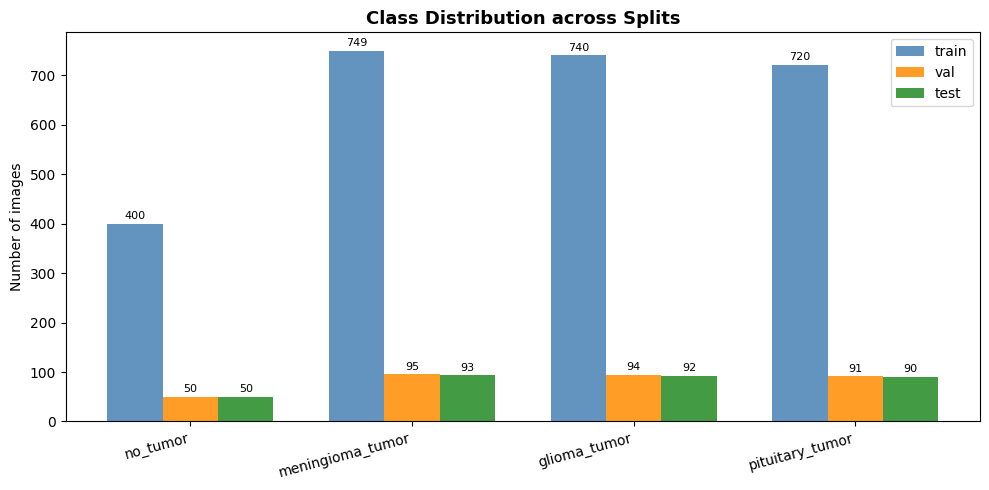

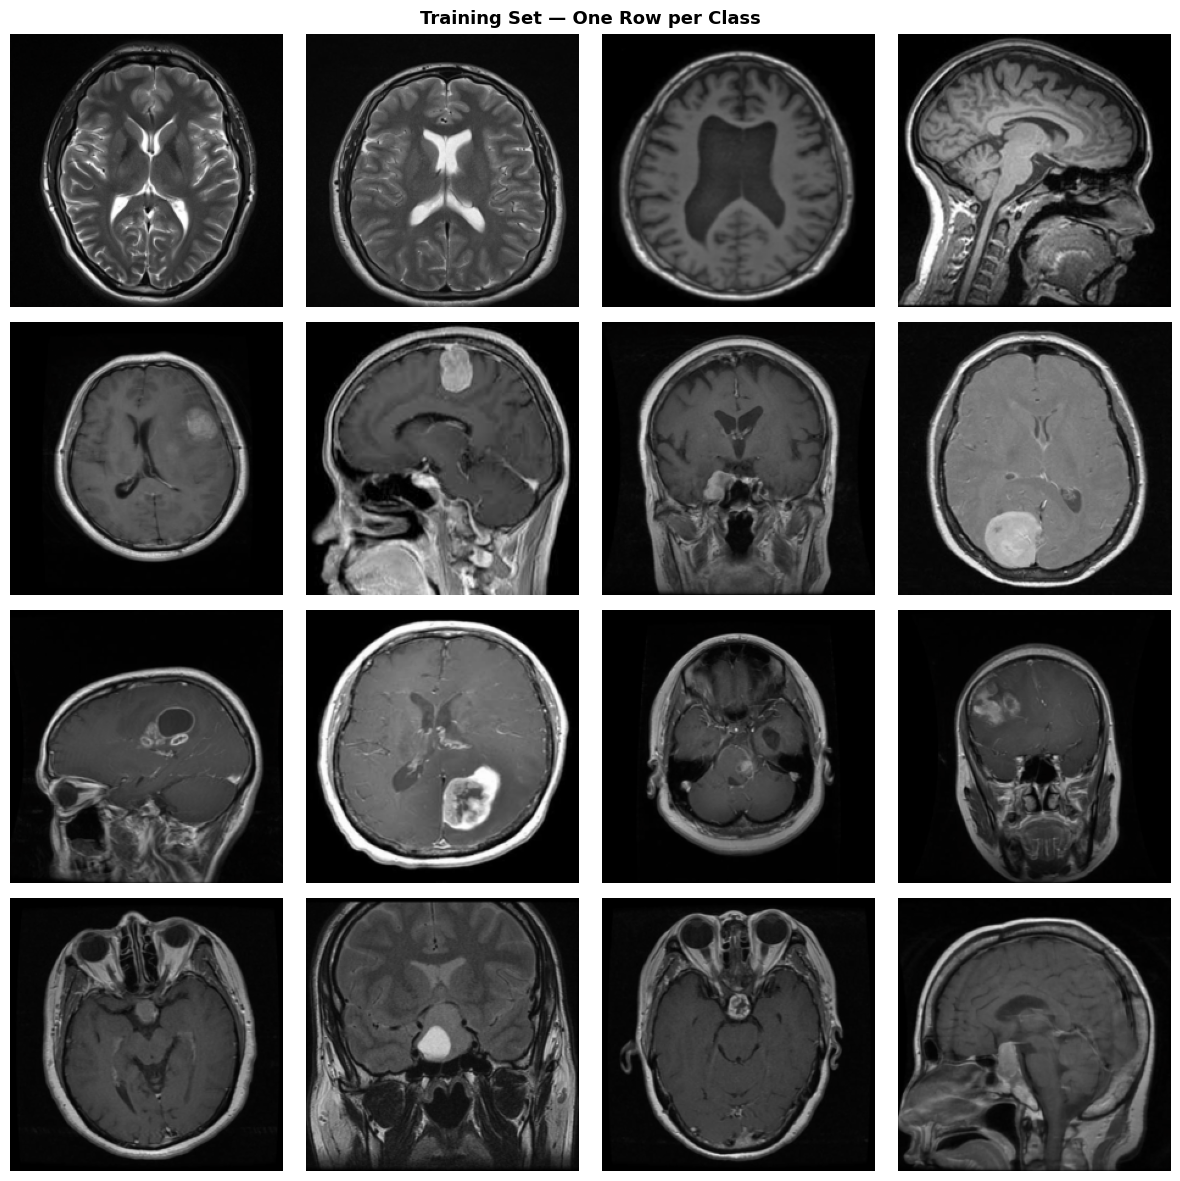

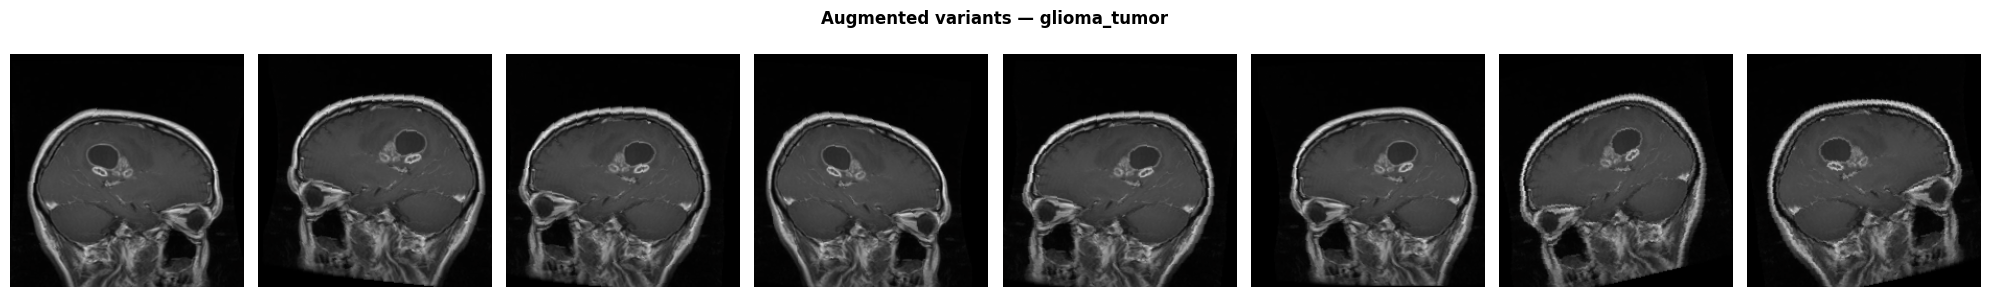

In [6]:
# Use default config to drive all visualisations
cfg = TrainingConfig()

show_class_distribution(cfg)
show_dataset_samples(cfg, samples_per_class=4)
show_augmentation_examples(cfg, cls_name='glioma_tumor')

## 3. Model

`build_model` is a factory keyed on `cfg.model_name`.
To add a new architecture, register it in the `_MODEL_REGISTRY` dict below — the rest of the pipeline stays unchanged.


In [7]:
def _build_resnet18_scratch(cfg: TrainingConfig) -> nn.Module:
    m = models.resnet18(weights=None)
    m.fc = nn.Sequential(
        nn.Dropout(p=cfg.dropout),
        nn.Linear(m.fc.in_features, NUM_CLASSES),
    )
    return m

def _build_rope_vit(cfg: TrainingConfig) -> nn.Module:
    return RoPEViT(
        image_size=cfg.image_size,
        patch_size=cfg.patch_size,
        num_classes=NUM_CLASSES,
        dim=cfg.vit_dim,
        depth=cfg.vit_depth,
        heads=cfg.vit_heads,
        mlp_dim=cfg.vit_mlp_dim,
        dropout=cfg.dropout,
    )

def _build_popevit(cfg: TrainingConfig) -> nn.Module:
    return PoPEViT(
        image_size=cfg.image_size,
        patch_size=cfg.patch_size,
        num_classes=NUM_CLASSES,
        dim=cfg.vit_dim,
        depth=cfg.vit_depth,
        heads=cfg.vit_heads,
        mlp_dim=cfg.vit_mlp_dim,
        dropout=cfg.dropout,
    )

_MODEL_REGISTRY = {
    'resnet18_scratch': _build_resnet18_scratch,
    'rope_vit':         _build_rope_vit,
    'popevit':          _build_popevit,
}


def build_model(cfg: TrainingConfig) -> nn.Module:
    """Instantiate the model specified by cfg.model_name and move it to DEVICE."""
    if cfg.model_name not in _MODEL_REGISTRY:
        raise ValueError(
            f'Unknown model {cfg.model_name!r}. '
            f'Registered: {list(_MODEL_REGISTRY.keys())}'
        )
    m = _MODEL_REGISTRY[cfg.model_name](cfg)
    total     = sum(p.numel() for p in m.parameters())
    trainable = sum(p.numel() for p in m.parameters() if p.requires_grad)
    print(f'{cfg.model_name}  |  total params: {total:,}  |  trainable: {trainable:,}')
    return m.to(DEVICE)

## 4. Training Infrastructure

All training functions are defined here and can be called with a `TrainingConfig`.  

In [8]:
# ── Optimiser factory ─────────────────────────────────────────────────────────
def _build_optimizer(model: nn.Module, cfg: TrainingConfig) -> torch.optim.Optimizer:
    p = model.parameters()
    if cfg.optimizer == 'adam':
        return torch.optim.Adam(p, lr=cfg.learning_rate, weight_decay=cfg.weight_decay)
    if cfg.optimizer == 'adamw':
        return torch.optim.AdamW(p, lr=cfg.learning_rate, weight_decay=cfg.weight_decay)
    if cfg.optimizer == 'sgd':
        return torch.optim.SGD(
            p, lr=cfg.learning_rate, weight_decay=cfg.weight_decay,
            momentum=0.9, nesterov=True,
        )
    raise ValueError(f'Unknown optimizer: {cfg.optimizer!r}')


# ── LR Scheduler factory ──────────────────────────────────────────────────────
def _build_scheduler(optimizer: torch.optim.Optimizer, cfg: TrainingConfig):
    """Epoch-level scheduler."""
    if cfg.scheduler == 'cosine':
        def lr_lambda(epoch: int) -> float:
            if epoch < cfg.warmup_epochs:
                # Linear warm-up: 1% -> 100% of base LR
                return max(0.01, epoch / max(1, cfg.warmup_epochs))
            # Cosine decay
            t = (epoch - cfg.warmup_epochs) / max(1, cfg.epochs - cfg.warmup_epochs)
            return max(0.0, 0.5 * (1.0 + np.cos(np.pi * t)))
        return torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)
    if cfg.scheduler == 'step':
        return torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.1)
    if cfg.scheduler == 'none':
        return None
    raise ValueError(f'Unknown scheduler: {cfg.scheduler!r}')


# ── AUROC ─────────────────────────────────────────────────────────────────────
def compute_auroc(
    labels: np.ndarray,
    probs:  np.ndarray,
) -> Dict[str, float]:
    """Per-class one-vs-rest AUROC + mean."""
    result: Dict[str, float] = {}
    for i, cls in enumerate(CLASS_NAMES):
        binary = (labels == i).astype(int)
        if binary.sum() == 0 or binary.sum() == len(binary):
            result[cls] = float('nan')   # undefined when only one class present
        else:
            result[cls] = float(roc_auc_score(binary, probs[:, i]))
    result['mean'] = float(np.nanmean(list(result.values())))
    return result


In [9]:
def train_one_epoch(
    model:     nn.Module,
    loader:    DataLoader,
    optimizer: torch.optim.Optimizer,
    criterion: nn.Module,
    device:    torch.device,
) -> Tuple[float, float]:
    """One training epoch. Returns (avg_loss, accuracy)."""
    model.train()
    total_loss, correct, total = 0.0, 0, 0

    bar = tqdm(loader, desc='  train', leave=False, unit='batch')
    for imgs, labels in bar:
        imgs   = imgs.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        logits = model(imgs)
        loss   = criterion(logits, labels)
        loss.backward()
        # Gradient clipping prevents unstable spikes
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        bs          = imgs.size(0)
        total_loss += loss.item() * bs
        correct    += (logits.argmax(1) == labels).sum().item()
        total      += bs
        bar.set_postfix(loss=f'{total_loss/total:.4f}', acc=f'{correct/total:.3f}')

    return total_loss / total, correct / total

In [10]:
@torch.no_grad()
def evaluate(
    model:     nn.Module,
    loader:    DataLoader,
    criterion: nn.Module,
    device:    torch.device,
) -> Dict[str, Any]:
    """Evaluate model on a DataLoader.

    Returns a dict with keys:
        loss, accuracy, auroc (dict), labels (np.ndarray), probs (np.ndarray)
    """
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_labels: List[np.ndarray] = []
    all_probs:  List[np.ndarray] = []

    for imgs, labels in tqdm(loader, desc='  eval ', leave=False, unit='batch'):
        imgs   = imgs.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        logits = model(imgs)
        loss   = criterion(logits, labels)
        probs  = logits.softmax(dim=1)

        bs          = imgs.size(0)
        total_loss += loss.item() * bs
        correct    += (probs.argmax(1) == labels).sum().item()
        total      += bs
        all_labels.append(labels.cpu().numpy())
        all_probs.append(probs.cpu().float().numpy())

    all_labels_np = np.concatenate(all_labels)
    all_probs_np  = np.concatenate(all_probs)

    return {
        'loss':     total_loss / total,
        'accuracy': correct / total,
        'auroc':    compute_auroc(all_labels_np, all_probs_np),
        'labels':   all_labels_np,
        'probs':    all_probs_np,
    }

In [ ]:
def train_model(cfg: TrainingConfig) -> Dict[str, Any]:
    """Full training run for a given config.

    Returns a history dict:
        train_loss, train_acc, val_loss, val_acc, val_auroc  -- list per epoch
        lr                                                   -- list per epoch
        test_metrics                                         -- final test evaluation
        model                                                -- best model weights loaded
        config                                               -- TrainingConfig used
    """
    set_seed(cfg.seed)
    os.makedirs(cfg.checkpoint_dir, exist_ok=True)

    sep = '=' * 62
    print(f'\n{sep}')
    print(f'  Run   : {cfg.run_name}')
    print(f'  Model : {cfg.model_name}')
    print(f'  LR    : {cfg.learning_rate}  |  BS : {cfg.batch_size}  |  Epochs : {cfg.epochs}')
    print(f'{sep}\n')

    # ── Data ──────────────────────────────────────────────────────────────
    loaders = get_dataloaders(cfg)
    print(f'  Train : {len(loaders["train"].dataset):,} samples')
    print(f'  Val   : {len(loaders["val"].dataset):,} samples')
    print(f'  Test  : {len(loaders["test"].dataset):,} samples\n')

    # ── Class weights (inverse frequency, normalised) ─────────────────────
    raw_train = BrainTumorDataset(
        os.path.join(cfg.data_dir, 'train'),
        transform=None,
        variants_per_image=1,
    )
    counts = np.zeros(NUM_CLASSES)
    for _, label_str, _ in raw_train.samples:
        counts[_LABEL_MAP[label_str]] += 1
    class_w = counts.sum() / (NUM_CLASSES * counts.clip(min=1))
    class_w = class_w / class_w.mean()   # normalise so mean weight == 1
    print('  Class weights:', {CLASS_NAMES[i]: f'{class_w[i]:.3f}' for i in range(NUM_CLASSES)})

    criterion = nn.CrossEntropyLoss(
        weight=torch.tensor(class_w, dtype=torch.float32).to(DEVICE)
    )

    # ── Model / optimiser / scheduler ─────────────────────────────────────
    model     = build_model(cfg)
    optimizer = _build_optimizer(model, cfg)
    scheduler = _build_scheduler(optimizer, cfg)

    # ── Training history ──────────────────────────────────────────────────
    history: Dict[str, Any] = {
        k: [] for k in ('train_loss', 'train_acc', 'val_loss', 'val_acc', 'val_auroc', 'lr')
    }
    best_auroc, patience_ctr, best_state = -1.0, 0, None

    # ── Epoch loop ────────────────────────────────────────────────────────
    for epoch in range(1, cfg.epochs + 1):
        t0 = time.time()
        current_lr = optimizer.param_groups[0]['lr']

        train_loss, train_acc = train_one_epoch(
            model, loaders['train'], optimizer, criterion, DEVICE
        )
        val_m     = evaluate(model, loaders['val'], criterion, DEVICE)
        val_auroc = val_m['auroc'].get('mean', float('nan'))

        if scheduler is not None:
            scheduler.step()

        # Record
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_m['loss'])
        history['val_acc'].append(val_m['accuracy'])
        history['val_auroc'].append(val_auroc)
        history['lr'].append(current_lr)

        print(
            f'Epoch {epoch:3d}/{cfg.epochs}'
            f'  train  loss={train_loss:.4f}  acc={train_acc:.3f}'
            f'  |  val  loss={val_m["loss"]:.4f}  acc={val_m["accuracy"]:.3f}'
            f'  AUROC={val_auroc:.4f}'
            f'  |  lr={current_lr:.2e}  [{time.time()-t0:.1f}s]'
        )

        # ── Checkpoint + early stopping ───────────────────────────────────
        if val_auroc > best_auroc:
            best_auroc   = val_auroc
            best_state   = deepcopy(model.state_dict())
            patience_ctr = 0
            ckpt = os.path.join(cfg.checkpoint_dir, f'{cfg.run_name}_best.pt')
            torch.save({'epoch': epoch, 'state_dict': best_state, 'config': asdict(cfg)}, ckpt)
            print(f'           -> New best val AUROC {best_auroc:.4f}  checkpoint: {ckpt}')
        else:
            patience_ctr += 1
            if patience_ctr >= cfg.early_stopping_patience:
                print(f'\n  Early stopping at epoch {epoch} (patience={cfg.early_stopping_patience})')
                break

    # ── Load best weights and evaluate on test set ─────────────────────────
    if best_state is not None:
        model.load_state_dict(best_state)
    test_m = evaluate(model, loaders['test'], criterion, DEVICE)

    dash = '-' * 55
    print(f'\n{dash}')
    print(f'  Test results  [{cfg.run_name}]')
    print(f'  Loss     : {test_m["loss"]:.4f}')
    print(f'  Accuracy : {test_m["accuracy"]:.4f}')
    for cls, auc in test_m['auroc'].items():
        marker = '  >' if cls == 'mean' else '   '
        print(f'{marker} AUROC [{cls:<22}]: {auc:.4f}')
    print(f'{dash}\n')

    history['test_metrics'] = test_m
    history['model']        = model
    history['config']       = cfg

    # Re-save checkpoint with full training history so it can be restored on load
    ckpt = os.path.join(cfg.checkpoint_dir, f'{cfg.run_name}_best.pt')
    saved_history = {k: v for k, v in history.items() if k not in ('model', 'config')}
    torch.save({'epoch': epoch, 'state_dict': best_state, 'config': asdict(cfg),
                'history': saved_history}, ckpt)

    return history


In [12]:
def load_or_train(cfg: TrainingConfig) -> Dict[str, Any]:
    """Load a checkpoint if it exists, otherwise train from scratch."""
    ckpt_path = os.path.join(cfg.checkpoint_dir, f'{cfg.run_name}_best.pt')
    if not os.path.isfile(ckpt_path):
        print(f'Checkpoint {ckpt_path} not found. Training model...')
        return train_model(cfg)

    print(f'Loading existing checkpoint for {cfg.run_name} from {ckpt_path}')
    checkpoint = torch.load(ckpt_path, map_location=DEVICE)
    model = build_model(cfg)
    model.load_state_dict(checkpoint['state_dict'])

    if 'history' in checkpoint:
        history = checkpoint['history']
        history['model']  = model
        history['config'] = cfg
        return history

    # Legacy checkpoint: recompute test metrics with the correct weighted criterion
    # Onkly here because I have trained a model without class weights, 
    # but I want to report the correct test metrics now that I've added them. 
    # Future checkpoints will include the history dict and skip this step.
    raw_train = BrainTumorDataset(
        os.path.join(cfg.data_dir, 'train'), transform=None, variants_per_image=1)
    counts = np.zeros(NUM_CLASSES)
    for _, label_str, _ in raw_train.samples:
        counts[_LABEL_MAP[label_str]] += 1
    class_w = counts.sum() / (NUM_CLASSES * counts.clip(min=1))
    class_w = class_w / class_w.mean()
    criterion = nn.CrossEntropyLoss(
        weight=torch.tensor(class_w, dtype=torch.float32).to(DEVICE))
    test_m = evaluate(model, get_dataloaders(cfg)['test'], criterion, DEVICE)
    return {'test_metrics': test_m, 'model': model, 'config': cfg}

## 5. Results & Plotting

In [13]:
def plot_training_curves(history: Dict[str, Any]) -> None:
    """Loss / accuracy / AUROC curves for a training run."""
    if 'train_loss' not in history:
        print(f'[{history["config"].run_name}] No training curve data available (loaded from legacy checkpoint).')
        return
    ep = range(1, len(history['train_loss']) + 1)
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    axes[0].plot(ep, history['train_loss'], label='train')
    axes[0].plot(ep, history['val_loss'],   label='val')
    axes[0].set_title('Loss')
    axes[0].set_xlabel('Epoch')
    axes[0].legend()

    axes[1].plot(ep, history['train_acc'], label='train')
    axes[1].plot(ep, history['val_acc'],   label='val')
    axes[1].set_title('Accuracy')
    axes[1].set_xlabel('Epoch')
    axes[1].legend()

    axes[2].plot(ep, history['val_auroc'], color='darkorange', label='val AUROC (mean)')
    axes[2].set_title('Validation AUROC (mean one-vs-rest)')
    axes[2].set_xlabel('Epoch')
    axes[2].set_ylim(0, 1)
    axes[2].legend()

    fig.suptitle(history['config'].run_name, fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()


def plot_per_class_auroc(history: Dict[str, Any]) -> None:
    """Bar chart of per-class AUROC on the test set."""
    auroc = {k: v for k, v in history['test_metrics']['auroc'].items() if k != 'mean'}
    mean  = history['test_metrics']['auroc'].get('mean', 0.0)

    fig, ax = plt.subplots(figsize=(8, 4))
    bars = ax.bar(list(auroc.keys()), list(auroc.values()), color='steelblue', alpha=0.85)
    ax.axhline(mean, color='red', linestyle='--', linewidth=1.5, label=f'mean = {mean:.3f}')
    ax.bar_label(bars, fmt='%.3f', padding=3)
    ax.set_ylim(0, 1.08)
    ax.set_title(f'Per-class AUROC (test set) — {history["config"].run_name}')
    ax.set_xlabel('Class')
    ax.set_ylabel('AUROC')
    ax.legend()
    plt.xticks(rotation=15, ha='right')
    plt.tight_layout()
    plt.show()


def plot_confusion_matrix(history: Dict[str, Any]) -> None:
    """Normalised confusion matrix on the test set."""
    tm    = history['test_metrics']
    preds = np.argmax(tm['probs'], axis=1)
    cm    = confusion_matrix(tm['labels'], preds, normalize='true')
    disp  = ConfusionMatrixDisplay(cm, display_labels=CLASS_NAMES)
    fig, ax = plt.subplots(figsize=(7, 6))
    disp.plot(ax=ax, colorbar=False, cmap='Blues', values_format='.2f')
    plt.xticks(rotation=20, ha='right')
    plt.title(f'Confusion Matrix (normalised) — {history["config"].run_name}')
    plt.tight_layout()
    plt.show()

## 6. CNN Baseline — ResNet-18 (from scratch)

Convolutional baseline trained without pretrained weights for a fair comparison with the ViT models.

In [14]:
cnn_cfg = TrainingConfig(
    run_name      = 'cnn_resnet18_scratch',
    model_name    = 'resnet18_scratch',
    dropout       = 0.3,
    warmup_epochs = 3,
    seed          = 42,
)

In [15]:
history_cnn = load_or_train(cnn_cfg)

Checkpoint checkpoints/cnn_resnet18_scratch_best.pt not found. Training model...

  Run   : cnn_resnet18_scratch


AttributeError: 'TrainingConfig' object has no attribute 'pretrained'

In [ ]:
plot_training_curves(history_cnn)
plot_per_class_auroc(history_cnn)
plot_confusion_matrix(history_cnn)

## 7. ViT Baseline — RoPE-ViT (from scratch)

Vision Transformer with Rotary Position Embeddings. Same architecture and hyperparameters as PoPE-ViT for a direct ablation of the positional encoding.

In [ ]:
rope_vit_cfg = TrainingConfig(
    run_name   = 'rope_vit',
    model_name = 'rope_vit',
    dropout    = 0.1,
    vit_dim     = 512,
    vit_depth   = 6,
    vit_heads   = 8,
    vit_mlp_dim = 1024,
    patch_size  = 16,
    seed       = 42,
)

In [ ]:
history_rope_vit = load_or_train(rope_vit_cfg)

In [ ]:
plot_training_curves(history_rope_vit)
plot_per_class_auroc(history_rope_vit)
plot_confusion_matrix(history_rope_vit)

## 8. Proposed Model — PoPE-ViT (from scratch)

Vision Transformer with Polar Positional Embeddings. Identical architecture to RoPE-ViT — only the positional encoding differs.

In [ ]:
popevit_cfg = TrainingConfig(
    run_name   = 'popevit',
    model_name = 'popevit',
    dropout    = 0.1,
    vit_dim     = 512,
    vit_depth   = 6,
    vit_heads   = 8,
    vit_mlp_dim = 1024,
    patch_size  = 16,
    seed       = 42,
)

In [ ]:
history_popevit = load_or_train(popevit_cfg)

In [ ]:
plot_training_curves(history_popevit)
plot_per_class_auroc(history_popevit)
plot_confusion_matrix(history_popevit)

## 7. Hyperparameter Experiments

The pipeline is designed for easy experimentation.  
Either override individual fields on a base config or use `run_grid_search` for an automated sweep.

In [ ]:
def run_grid_search(
    param_grid: Dict[str, List[Any]],
    base_cfg:   TrainingConfig,
) -> List[Dict[str, Any]]:
    """Exhaustive grid search over param_grid.

    Parameters
    ----------
    param_grid : mapping from TrainingConfig field name -> list of values to try
    base_cfg   : default values for fields not in param_grid

    Example
    -------
    results = run_grid_search(
        {'learning_rate': [1e-4, 3e-4], 'dropout': [0.2, 0.4]},
        base_cfg=baseline_cfg,
    )
    """
    keys   = list(param_grid.keys())
    combos = list(itertools.product(*param_grid.values()))
    results: List[Dict[str, Any]] = []

    for i, combo in enumerate(combos, 1):
        kwargs   = dict(zip(keys, combo))
        run_name = '_'.join(f'{k}={v}' for k, v in kwargs.items())
        cfg      = TrainingConfig(**{**asdict(base_cfg), **kwargs, 'run_name': run_name})
        print(f'\n[{i}/{len(combos)}] Grid search config: {kwargs}')
        hist = train_model(cfg)
        results.append({
            'config':     kwargs,
            'test_auroc': hist['test_metrics']['auroc'].get('mean', float('nan')),
            'history':    hist,
        })

    results.sort(key=lambda x: x['test_auroc'], reverse=True)
    print('\n── Grid search results (best first) ────────────────────────')
    for r in results:
        print(f'  AUROC {r["test_auroc"]:.4f}  |  {r["config"]}')
    return results


# ── Example: automated grid search ───────────────────────────────────────────
# Uncomment to run

# gs_results = run_grid_search(
#     param_grid = {
#         'learning_rate': [1e-4, 3e-4],
#         'dropout':       [0.2, 0.4],
#     },
#     base_cfg = baseline_cfg,
# )


## 8. Results Summary

Add all completed runs to `histories` to generate a comparison table.

In [ ]:
summarise_runs([history_cnn, history_rope_vit, history_popevit])

,model,lr,dropout,bs,test_acc,auroc_no_tumor,auroc_meningioma_tumor,auroc_glioma_tumor,auroc_pituitary_tumor,auroc_mean
run,,,,,,,,,,
baseline_resnet18,resnet18,0.0003,0.3,32,0.9723,0.9999,0.9994,0.9982,0.9998,0.9993
